# 02 - Feature Engineering

Two problems to solve before any model sees this data:

1. **Cross-well calibration drift.** Different wells, sometimes different
   logging runs/tools -- GR in one well isn't guaranteed to mean the same
   absolute number as GR in another. Pooling wells without correcting for
   this teaches the model well identity instead of facies.
2. **Row independence is a bad assumption.** Facies are beds, not points --
   a depth sample's rock type is correlated with its neighbors. A model
   that only sees one depth at a time is throwing that structure away.

This notebook builds and sanity-checks the two feature representations
used downstream: a per-well-normalized tabular matrix (for LDA / RF /
XGBoost) and a sliding depth-window tensor (for the CNN).

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_raw, LOG_CURVES, split_blind_well
from src.features import normalize_by_well, add_window_features, build_feature_matrix, sliding_sequences

df = load_raw()
df[LOG_CURVES].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
GR,66.135769,30.854826,13.250000,361.150
ILD_log10,0.642719,0.241845,-0.025949,1.480
DeltaPHI,3.559642,5.228948,-21.832000,18.600
PHIND,13.483213,7.698980,0.550000,84.400
PE,3.725014,0.896152,0.200000,8.094
NM_M,1.498453,0.500075,1.000000,2.000
RELPOS,0.520287,0.286792,0.010000,1.000


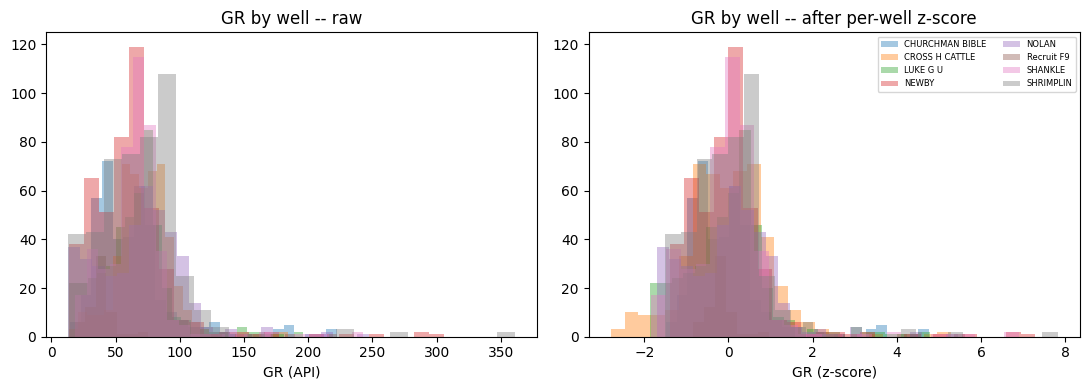

In [2]:
# GR alone, before vs after per-well normalization
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for well, g in df.groupby("Well Name", observed=True):
    axes[0].hist(g["GR"], bins=25, alpha=0.4, label=well)
axes[0].set_title("GR by well -- raw")
axes[0].set_xlabel("GR (API)")

norm = normalize_by_well(df)
for well, g in norm.groupby("Well Name", observed=True):
    axes[1].hist(g["GR"], bins=25, alpha=0.4, label=well)
axes[1].set_title("GR by well -- after per-well z-score")
axes[1].set_xlabel("GR (z-score)")
axes[1].legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.savefig("../figures/gr_normalization_before_after.png", dpi=130)
plt.show()

The raw histograms show real spread in where each well's GR
distribution sits -- not huge here (Council Grove wells are all from
the same field and era), but enough that the normalized version pulls
distributions closer together without erasing the facies-driven shape
of each well's histogram. On a dataset spanning multiple fields or
vintages this step usually matters a lot more than it does here, but
it costs nothing and removes one confound, so it stays in.

In [3]:
windowed = add_window_features(normalize_by_well(df))
new_cols = [c for c in windowed.columns if c not in df.columns]
print("engineered columns:", new_cols)
windowed[new_cols].head()

engineered columns: ['GR_rmean', 'GR_rstd', 'ILD_log10_rmean', 'ILD_log10_rstd', 'PHIND_rmean', 'PHIND_rstd', 'GR_grad', 'ILD_log10_grad', 'PHIND_grad']


,GR_rmean,GR_rstd,ILD_log10_rmean,ILD_log10_rstd,PHIND_rmean,PHIND_rstd,GR_grad,ILD_log10_grad,PHIND_grad
0,0.237119,0.021449,0.005670,0.012881,0.063247,0.107105,0.021716,-0.012881,0.122246
1,0.289711,0.106632,-0.000770,0.016630,0.091693,0.104328,0.021448,-0.012881,0.106730
2,0.259497,0.114423,-0.011505,0.027992,0.115719,0.105117,0.105095,-0.012881,0.051719
3,0.240837,0.129931,-0.035550,0.043216,0.171012,0.060119,-0.059920,-0.023616,0.023509
4,0.216493,0.141635,-0.062172,0.051651,0.222355,0.065499,-0.162603,-0.040791,0.025390


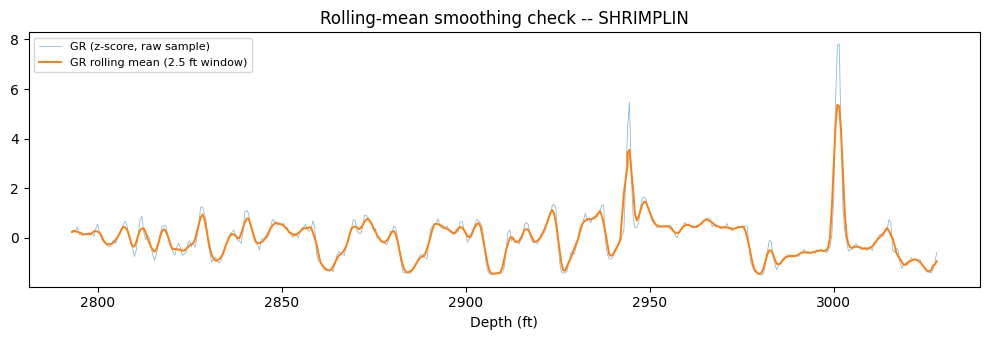

In [4]:
# does the 5-sample rolling mean actually track bed-scale structure,
# or is it just smoothing away signal? check against one well visually
well = "SHRIMPLIN"
w = windowed[windowed["Well Name"] == well].sort_values("Depth")
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(w["Depth"], w["GR"], lw=0.6, alpha=0.5, label="GR (z-score, raw sample)")
ax.plot(w["Depth"], w["GR_rmean"], lw=1.4, label="GR rolling mean (2.5 ft window)")
ax.set_xlabel("Depth (ft)"); ax.legend(fontsize=8)
ax.set_title(f"Rolling-mean smoothing check -- {well}")
plt.tight_layout()
plt.savefig("../figures/rolling_mean_check.png", dpi=130)
plt.show()

Reasonable -- the rolling mean tracks the bed-scale trend without
flattening the sharper transitions entirely. A window much wider than
this (say 20+ samples / 10 ft) started washing out thin beds when I
tried it, so 5 samples (2.5 ft) is a compromise, not a default.

In [5]:
Xtr, ytr, cols = build_feature_matrix(df)
print("tabular feature matrix:", Xtr.shape)
print("columns:", cols)

tabular feature matrix: (3232, 16)
columns: ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE', 'NM_M', 'RELPOS', 'GR_rmean', 'GR_rstd', 'ILD_log10_rmean', 'ILD_log10_rstd', 'PHIND_rmean', 'PHIND_rstd', 'GR_grad', 'ILD_log10_grad', 'PHIND_grad']


In [6]:
train, blind = split_blind_well(df, "SHANKLE")
Xtr_seq, ytr_seq = sliding_sequences(train, window=9)
Xbl_seq, ybl_seq = sliding_sequences(blind, window=9)
print("sequence tensor shape (n_samples, window, n_curves):", Xtr_seq.shape)
print("value range after normalization:", Xtr_seq.min().round(2), "to", Xtr_seq.max().round(2))

sequence tensor shape (n_samples, window, n_curves): (2783, 9, 7)
value range after normalization: -6.4 to 7.82


Window = 9 samples = 4.5 ft of context centered on the labeled depth,
padded with edge-replication at well tops/bottoms so no samples get
dropped. I tried window=5 and window=15 too -- 5 didn't add much over
the un-windowed tabular features, 15 started pulling in enough of the
neighboring bed that thin beds got smeared together in early CNN runs.
9 was the middle ground that actually changed the training curves in
`05`.

Both representations are now checked and ready. Next: `03` builds the
classical (LDA) and Random Forest baselines on the tabular matrix.